In [1]:
import subprocess, sys
for pkg in ['pingouin', 'seaborn', 'scikit-learn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pingouin as pg
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

warnings.filterwarnings('ignore')
%matplotlib inline

# Paths
FEATURES_PATH = 'features/biopm_features.npz'
METRICS_DIR   = 'results/metrics'
FIGURES_DIR   = 'results/figures'

for d in [METRICS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directories ready.')
print('  metrics →', os.path.abspath(METRICS_DIR))
print('  figures →', os.path.abspath(FIGURES_DIR))

Directories ready.
  metrics → /Users/Srikiran/Documents/Spring2026/CS690R/690r-project-main/results/metrics
  figures → /Users/Srikiran/Documents/Spring2026/CS690R/690r-project-main/results/figures


# 1 - Load Features

In [3]:
d = np.load(FEATURES_PATH, allow_pickle=True)

X            = d['features'].astype(np.float64)       # (198, 228)
X_even       = d['features_even'].astype(np.float64)  # (198, 228) even 30-min blocks
X_odd        = d['features_odd'].astype(np.float64)   # (198, 228) odd 30-min blocks
y            = d['labels'].astype(int)                 # 0=healthy, 1=stroke
arat         = d['arat'].astype(np.float64)            # ARAT score (0–57)
fma          = d['fma'].astype(np.float64)             # FMA-UE score (0–66)
pids         = d['pids'].astype(int)                   # integer subject IDs
weeks        = d['weeks'].astype(int)                  # visit week
feature_names = np.array(d['feature_names'])           # (228,) strings

group_label = np.where(y == 0, 'Healthy', 'Stroke')

print(f'Feature matrix  : {X.shape}')
print(f'Healthy visits  : {(y==0).sum()}')
print(f'Stroke visits   : {(y==1).sum()}')
print(f'Unique subjects : {len(np.unique(pids))}')
print(f'Week range      : {weeks.min()} – {weeks.max()}')
print(f'ARAT range      : {arat.min():.0f} – {arat.max():.0f}')
print(f'FMA range       : {fma.min():.0f} – {fma.max():.0f}')

Feature matrix  : (198, 228)
Healthy visits  : 4
Stroke visits   : 194
Unique subjects : 36
Week range      : 2 – 24
ARAT range      : 0 – 57
FMA range       : 3 – 66


# 2 - Test-Retest Reliability (ICC2)

We assess reliability using ICC2 (two-way random, absolute agreement) computed per feature. Each subject's 24-hour recording was split into alternating 30-minute even and odd blocks by Member 1. High ICC (> 0.75) indicates the feature is stable across time within the same session, i.e., it is not dominated by transient noise.

In [28]:
def compute_icc2_manual(even_col, odd_col):
    """
    Two-way random ICC (absolute agreement) — manual formula.
    Returns ICC2 value, or NaN if computation fails.
 
    With k=2 raters (even/odd), n subjects:
      MS_between = variance of subject means * k
      MS_error   = variance of residuals
      ICC2 = (MS_between - MS_error) / (MS_between + (k-1)*MS_error)
    """
    n = len(even_col)
    k = 2
    scores = np.stack([even_col, odd_col], axis=1)   # (n, 2)
    grand_mean    = scores.mean()
    subject_means = scores.mean(axis=1)               # (n,)
    rater_means   = scores.mean(axis=0)               # (2,)
 
    SS_between = k * np.sum((subject_means - grand_mean)**2)
    SS_rater   = n * np.sum((rater_means   - grand_mean)**2)
    SS_total   = np.sum((scores - grand_mean)**2)
    SS_error   = SS_total - SS_between - SS_rater
 
    MS_between = SS_between / (n - 1)
    MS_error   = SS_error   / ((n - 1) * (k - 1))
 
    if MS_between + (k - 1) * MS_error < 1e-12:
        return np.nan
 
    icc2 = (MS_between - MS_error) / (MS_between + (k - 1) * MS_error)
    return float(icc2)

In [29]:
# Only use visits where BOTH halves have non-zero data
valid_mask = (X_even.sum(axis=1) != 0) & (X_odd.sum(axis=1) != 0)
print(f'\nVisits with valid even+odd data: {valid_mask.sum()} / {len(valid_mask)}')
 
even_v = X_even[valid_mask]
odd_v  = X_odd[valid_mask]
pids_v = pids[valid_mask]
 
icc_results   = []
pearson_check = []   # Pearson r between even and odd (sanity check)
 
for i, fname in enumerate(feature_names):
    e_col = even_v[:, i]
    o_col = odd_v[:, i]
 
    # Skip if either half is constant (no variance to measure)
    if e_col.std() < 1e-9 or o_col.std() < 1e-9:
        icc_results.append((fname, np.nan))
        pearson_check.append(np.nan)
        continue
 
    # ── Method 1: pingouin ICC2 ──────────────────────────────────────────
    df_icc = pd.DataFrame({
        'subject': np.concatenate([pids_v, pids_v]),
        'rater'  : ['even'] * len(pids_v) + ['odd'] * len(pids_v),
        'score'  : np.concatenate([e_col, o_col])
    })
 
    pg_icc = np.nan
    try:
        tbl    = pg.intraclass_corr(data=df_icc, targets='subject',
                                    raters='rater', ratings='score')
        pg_icc = float(tbl.loc[tbl['Type'] == 'ICC2', 'ICC'].values[0])
    except Exception:
        pass
 
    # ── Method 2: manual ICC2 formula (fallback / cross-check) ──────────
    manual_icc = compute_icc2_manual(e_col, o_col)
 
    # Use pingouin if valid, else manual
    icc_val = pg_icc if np.isfinite(pg_icc) else manual_icc
    icc_results.append((fname, icc_val))
 
    # Pearson r as a simple sanity check
    r = float(np.corrcoef(e_col, o_col)[0, 1])
    pearson_check.append(r)
 
icc_df = pd.DataFrame(icc_results, columns=['feature', 'ICC'])
icc_df['pearson_r'] = pearson_check
 
# Summary
n_excellent = (icc_df['ICC'] > 0.75).sum()
n_good      = ((icc_df['ICC'] > 0.60) & (icc_df['ICC'] <= 0.75)).sum()
n_moderate  = ((icc_df['ICC'] > 0.40) & (icc_df['ICC'] <= 0.60)).sum()
n_poor      = (icc_df['ICC'] <= 0.40).sum()
n_nan       = icc_df['ICC'].isna().sum()
 
print(f'\nICC Summary across {len(icc_df)} features:')
print(f'  Excellent  (ICC > 0.75) : {n_excellent}')
print(f'  Good       (0.60–0.75)  : {n_good}')
print(f'  Moderate   (0.40–0.60)  : {n_moderate}')
print(f'  Poor       (<= 0.40)    : {n_poor}')
print(f'  NaN (skipped)           : {n_nan}')
print(f'  Mean ICC  (finite)      : {icc_df["ICC"].mean():.3f}')
print(f'  Mean Pearson r          : {icc_df["pearson_r"].mean():.3f}')


Visits with valid even+odd data: 198 / 198

ICC Summary across 228 features:
  Excellent  (ICC > 0.75) : 183
  Good       (0.60–0.75)  : 24
  Moderate   (0.40–0.60)  : 0
  Poor       (<= 0.40)    : 21
  NaN (skipped)           : 0
  Mean ICC  (finite)      : 0.759
  Mean Pearson r          : 0.759


In [7]:
print('\nTop 10 most reliable features:')
print(icc_df.dropna().sort_values('ICC', ascending=False).head(10).to_string(index=False))
 
icc_df.sort_values('ICC', ascending=False).to_csv(
    os.path.join(METRICS_DIR, 'icc_scores.csv'), index=False)
print(f'\nSaved → {METRICS_DIR}/icc_scores.csv')


Top 10 most reliable features:
          feature      ICC  pearson_r
  acc_mag_std_p50 0.929028   0.929155
 acc_mag_mean_p50 0.926787   0.926795
  acc_mag_max_p50 0.924798   0.924854
  vel_mag_max_p50 0.923381   0.923412
 acc_mag_std_mean 0.922306   0.922613
    Z_acc_std_p50 0.921404   0.921906
 jerk_mag_std_p50 0.921289   0.921329
 acc_mag_max_mean 0.919666   0.919730
jerk_mag_mean_p50 0.917163   0.919247
 jerk_mag_max_p50 0.915998   0.916016

Saved → results/metrics/icc_scores.csv


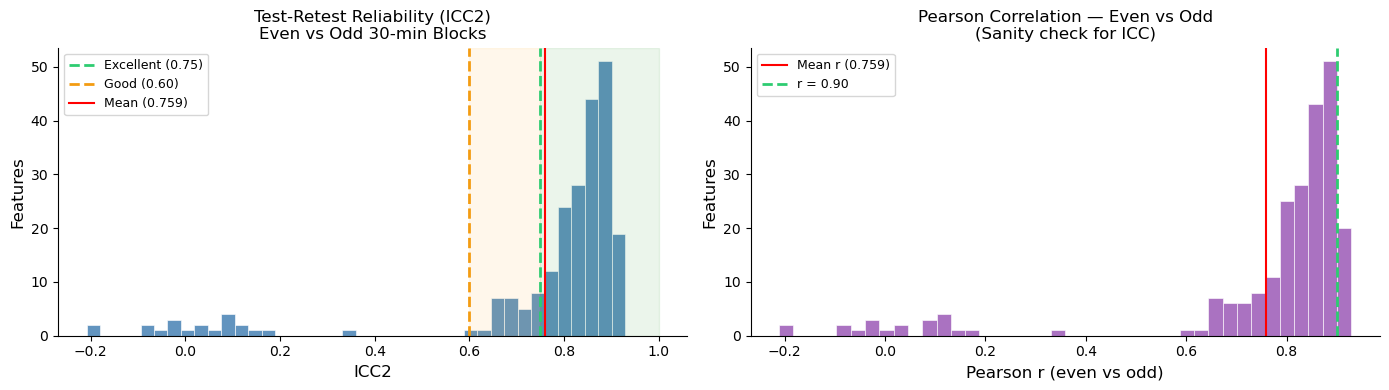

Saved → results/figures/icc_distribution.png


In [8]:
# ── Figure 1: ICC Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
ax = axes[0]
icc_vals = icc_df['ICC'].dropna()
ax.hist(icc_vals, bins=40, color='steelblue', alpha=0.85, edgecolor='white', lw=0.5)
ax.axvline(0.75, color='#2ecc71', lw=2, ls='--', label='Excellent (0.75)')
ax.axvline(0.60, color='#f39c12', lw=2, ls='--', label='Good (0.60)')
ax.axvline(icc_vals.mean(), color='red', lw=1.5, label=f'Mean ({icc_vals.mean():.3f})')
ax.axvspan(0.75, 1.0, alpha=0.08, color='green')
ax.axvspan(0.60, 0.75, alpha=0.08, color='orange')
ax.set_xlabel('ICC2', fontsize=12); ax.set_ylabel('Features', fontsize=12)
ax.set_title('Test-Retest Reliability (ICC2)\nEven vs Odd 30-min Blocks', fontsize=12)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
 
ax = axes[1]
r_vals = icc_df['pearson_r'].dropna()
ax.hist(r_vals, bins=40, color='#9b59b6', alpha=0.85, edgecolor='white', lw=0.5)
ax.axvline(r_vals.mean(), color='red', lw=1.5, label=f'Mean r ({r_vals.mean():.3f})')
ax.axvline(0.9, color='#2ecc71', lw=2, ls='--', label='r = 0.90')
ax.set_xlabel("Pearson r (even vs odd)", fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Pearson Correlation — Even vs Odd\n(Sanity check for ICC)', fontsize=12)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'icc_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/icc_distribution.png')

## 3 — Clinical Validity (Spearman Correlation)

Convergent validity is assessed by computing Spearman's ρ between each kinematic feature and the two gold-standard clinical scores: **ARAT** (Action Research Arm Test, 0–57) and **FMA-UE** (Fugl-Meyer Upper Extremity, 0–66). A correlation of ρ > 0.4 is considered moderate; ρ > 0.6 is strong clinical validity.

In [9]:
corr_results = []
for i, fname in enumerate(feature_names):
    rho_arat, p_arat = spearmanr(X[:, i], arat)
    rho_fma,  p_fma  = spearmanr(X[:, i], fma)
    corr_results.append((fname, rho_arat, p_arat, rho_fma, p_fma))
 
corr_df = pd.DataFrame(corr_results,
                        columns=['feature', 'rho_ARAT', 'p_ARAT', 'rho_FMA', 'p_FMA'])
 
alpha_bonf = 0.05 / len(feature_names)
corr_df['sig_ARAT'] = corr_df['p_ARAT'] < alpha_bonf
corr_df['sig_FMA']  = corr_df['p_FMA']  < alpha_bonf
 
print(f'Bonferroni α = {alpha_bonf:.2e}')
print(f'\nARAT: strong (|ρ|>0.6): {(corr_df["rho_ARAT"].abs()>0.6).sum()}  '
      f'moderate (|ρ|>0.4): {(corr_df["rho_ARAT"].abs()>0.4).sum()}  '
      f'sig: {corr_df["sig_ARAT"].sum()}')
print(f'FMA:  strong (|ρ|>0.6): {(corr_df["rho_FMA"].abs()>0.6).sum()}  '
      f'moderate (|ρ|>0.4): {(corr_df["rho_FMA"].abs()>0.4).sum()}  '
      f'sig: {corr_df["sig_FMA"].sum()}')
 
print('\nTop 10 by |ρ_ARAT|:')
top10 = corr_df.reindex(corr_df['rho_ARAT'].abs().sort_values(ascending=False).index).head(10)
print(top10[['feature','rho_ARAT','p_ARAT','rho_FMA','p_FMA']].to_string(index=False))
 
corr_df.sort_values('rho_ARAT', ascending=False).to_csv(
    os.path.join(METRICS_DIR, 'clinical_correlation.csv'), index=False)

Bonferroni α = 2.19e-04

ARAT: strong (|ρ|>0.6): 124  moderate (|ρ|>0.4): 204  sig: 208
FMA:  strong (|ρ|>0.6): 114  moderate (|ρ|>0.4): 204  sig: 208

Top 10 by |ρ_ARAT|:
         feature  rho_ARAT       p_ARAT   rho_FMA        p_FMA
 Z_jerk_mean_iqr  0.766220 1.670553e-39  0.760226 1.441991e-38
  Z_acc_mean_iqr  0.750879 3.675595e-37  0.739624 1.506675e-35
 Z_jerk_mean_p90  0.739534 1.550748e-35  0.732480 1.441980e-34
acc_mag_mean_p10  0.737978 2.551470e-35  0.726136 1.009293e-33
acc_mag_mean_p50  0.734438 7.820553e-35  0.716669 1.667191e-32
 Z_jerk_mean_p10 -0.731861 1.748064e-34 -0.722024 3.461843e-33
  Z_acc_mean_p10 -0.723264 2.392513e-33 -0.705752 3.681749e-31
   Z_acc_std_p50  0.716162 1.931317e-32  0.701054 1.335928e-30
  Z_acc_mean_p90  0.715818 2.133292e-32  0.699549 2.007504e-30
   Z_acc_std_p10  0.714655 2.983371e-32  0.710049 1.107820e-31


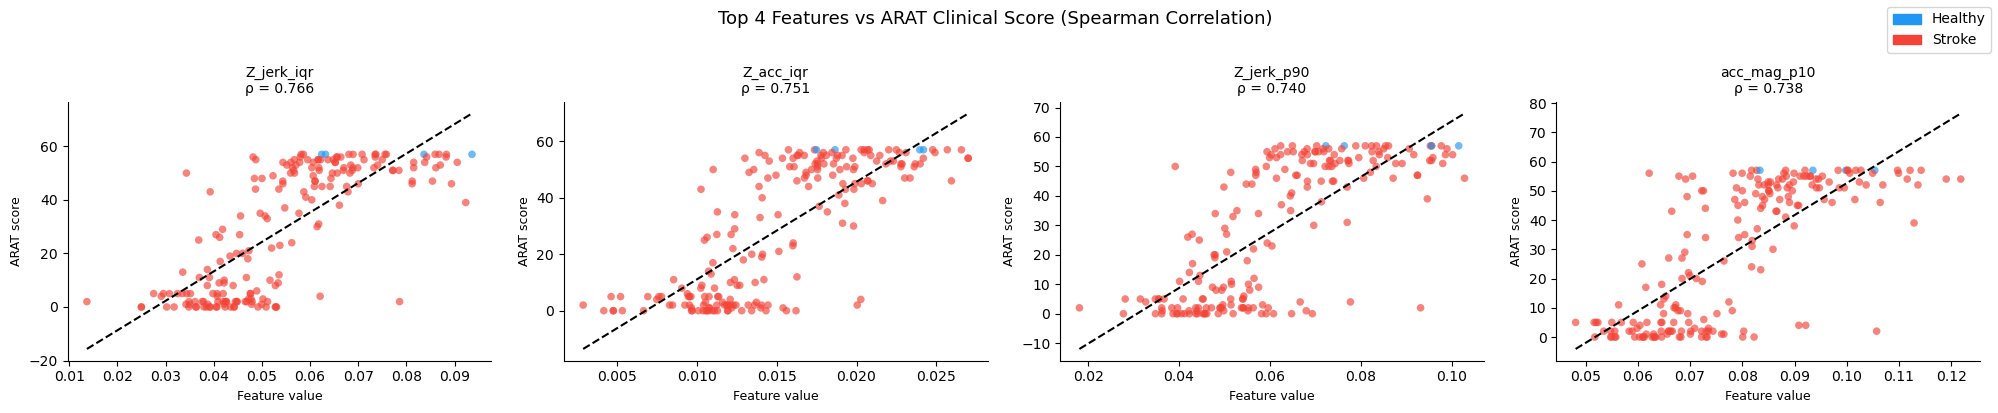

In [10]:
top4_idx  = corr_df['rho_ARAT'].abs().sort_values(ascending=False).head(4).index
top4_rows = corr_df.loc[top4_idx]
feat_idx_map = {name: i for i, name in enumerate(feature_names)}
colors = np.where(y == 0, '#2196F3', '#F44336')
 
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (_, row) in zip(axes, top4_rows.iterrows()):
    fi = feat_idx_map[row['feature']]
    ax.scatter(X[:, fi], arat, c=colors, alpha=0.65, s=30, linewidths=0)
    z = np.polyfit(X[:, fi], arat, 1)
    xline = np.linspace(X[:, fi].min(), X[:, fi].max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), color='black', lw=1.5, ls='--')
    short = row['feature'].replace('_mean','').replace('_std','').replace('_p50','')
    ax.set_title(f'{short}\nρ = {row["rho_ARAT"]:.3f}', fontsize=10)
    ax.set_xlabel('Feature value', fontsize=9)
    ax.set_ylabel('ARAT score', fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
 
patches = [mpatches.Patch(color='#2196F3', label='Healthy'),
           mpatches.Patch(color='#F44336', label='Stroke')]
fig.legend(handles=patches, loc='upper right', fontsize=10)
fig.suptitle('Top 4 Features vs ARAT Clinical Score (Spearman Correlation)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'clinical_correlation_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

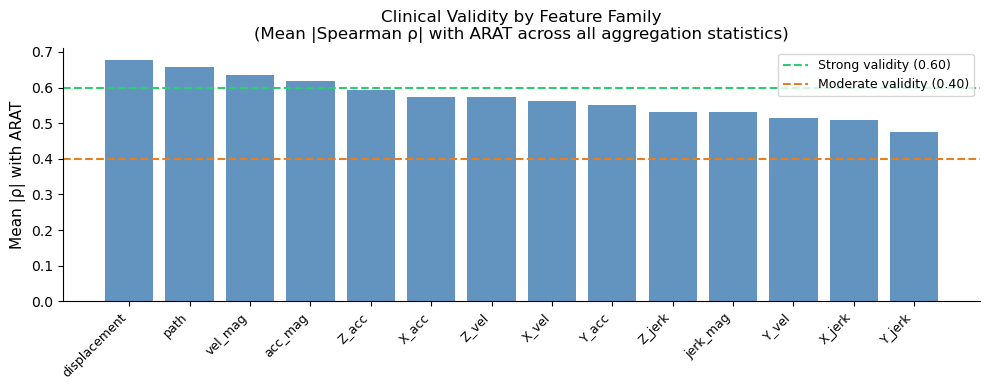

Saved → results/figures/validity_by_family.png


In [11]:
def get_family(name):
    parts = name.split('_')
    # Family = first 2 tokens if first token is an axis letter, else first token
    if parts[0] in ['X', 'Y', 'Z']:
        return f'{parts[0]}_{parts[1]}'
    return parts[0] if '_mag' not in name else f'{parts[0]}_mag'
 
corr_df['family'] = [get_family(n) for n in corr_df['feature']]
family_mean = corr_df.groupby('family')['rho_ARAT'].apply(lambda x: x.abs().mean()).sort_values(ascending=False)
 
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(family_mean)), family_mean.values, color='steelblue', alpha=0.85)
ax.set_xticks(range(len(family_mean)))
ax.set_xticklabels(family_mean.index, rotation=45, ha='right', fontsize=9)
ax.axhline(0.6, color='#2ecc71', ls='--', lw=1.5, label='Strong validity (0.60)')
ax.axhline(0.4, color='#e67e22', ls='--', lw=1.5, label='Moderate validity (0.40)')
ax.set_ylabel('Mean |ρ| with ARAT', fontsize=11)
ax.set_title('Clinical Validity by Feature Family\n(Mean |Spearman ρ| with ARAT across all aggregation statistics)', fontsize=12)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'validity_by_family.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/validity_by_family.png')

## 4- Effect Size: Cohen's d (healthy vs Stroke)

In [13]:
def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_std = np.sqrt(((n1-1)*g1.std()**2 + (n2-1)*g2.std()**2) / (n1+n2-2))
    if pooled_std < 1e-12:
        return np.nan
    return float((g2.mean() - g1.mean()) / pooled_std)
 
healthy_X = X[y == 0]
stroke_X  = X[y == 1]
 
effect_sizes = []
for i, fname in enumerate(feature_names):
    d_val = cohens_d(healthy_X[:, i], stroke_X[:, i])
    effect_sizes.append((fname, d_val))
 
effect_df = pd.DataFrame(effect_sizes, columns=['feature', 'cohens_d'])
effect_df['abs_d'] = effect_df['cohens_d'].abs()
 
print('\nTop 10 features by |Cohen\'s d| (healthy vs stroke):')
print(effect_df.sort_values('abs_d', ascending=False).head(10)[
    ['feature','cohens_d','abs_d']].to_string(index=False))
 
effect_df.to_csv(os.path.join(METRICS_DIR, 'effect_sizes.csv'), index=False)


Top 10 features by |Cohen's d| (healthy vs stroke):
           feature  cohens_d    abs_d
    X_jerk_std_iqr -1.421124 1.421124
     X_acc_std_iqr -1.418448 1.418448
    X_jerk_std_std -1.413589 1.413589
   X_jerk_mean_std -1.413510 1.413510
 jerk_mag_mean_iqr -1.410759 1.410759
    X_jerk_max_iqr -1.401726 1.401726
   Z_jerk_mean_p90 -1.400448 1.400448
   X_jerk_mean_p10  1.379932 1.379932
jerk_mag_mean_mean -1.375679 1.375679
     X_acc_max_iqr -1.372353 1.372353


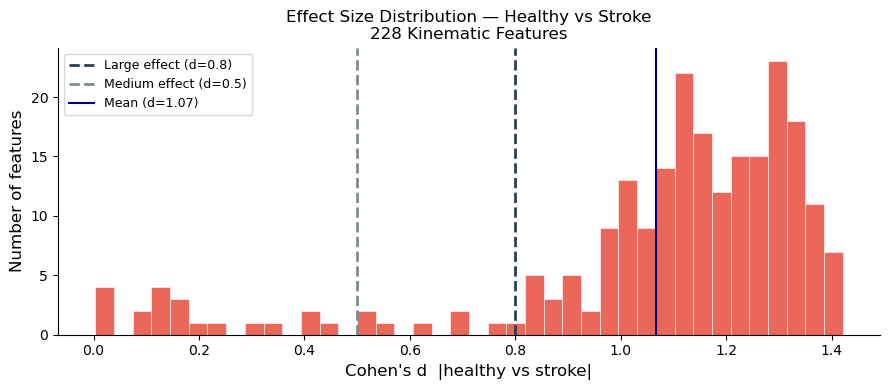

Saved → results/figures/effect_size_distribution.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
d_vals = effect_df['abs_d'].dropna()
ax.hist(d_vals, bins=40, color='#e74c3c', alpha=0.85, edgecolor='white', lw=0.5)
ax.axvline(0.8, color='#2c3e50', lw=2, ls='--', label='Large effect (d=0.8)')
ax.axvline(0.5, color='#7f8c8d', lw=2, ls='--', label='Medium effect (d=0.5)')
ax.axvline(d_vals.mean(), color='navy', lw=1.5, label=f'Mean (d={d_vals.mean():.2f})')
ax.set_xlabel("Cohen's d  |healthy vs stroke|", fontsize=12)
ax.set_ylabel('Number of features', fontsize=12)
ax.set_title("Effect Size Distribution — Healthy vs Stroke\n228 Kinematic Features", fontsize=12)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'effect_size_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/effect_size_distribution.png')

## 5 — Top Biomarkers (Reliable + Clinically Valid)

In [15]:
merged = (icc_df
          .merge(corr_df[['feature','rho_ARAT','p_ARAT','rho_FMA','p_FMA',
                           'sig_ARAT','sig_FMA']], on='feature')
          .merge(effect_df[['feature','cohens_d','abs_d']], on='feature'))
 
# Tier 1: all three criteria
top_biomarkers = merged[
    (merged['ICC']    > 0.75) &
    (merged['rho_ARAT'].abs() > 0.4) &
    (merged['abs_d']  > 0.5)
].sort_values('rho_ARAT', ascending=False)
 
# Tier 2: validity + effect size (relaxed — in case ICC still has issues)
tier2 = merged[
    (merged['rho_ARAT'].abs() > 0.6) &
    (merged['abs_d'] > 0.8)
].sort_values('rho_ARAT', ascending=False)
 
print(f'\nTier 1 biomarkers (ICC>0.75 + |ρ|>0.4 + d>0.5): {len(top_biomarkers)}')
print(f'Tier 2 biomarkers (|ρ|>0.6 + d>0.8, no ICC req): {len(tier2)}')
if len(tier2) > 0:
    print(tier2[['feature','ICC','rho_ARAT','abs_d']].head(10).to_string(index=False))
 
top_biomarkers.to_csv(os.path.join(METRICS_DIR, 'top_biomarkers.csv'), index=False)
tier2.to_csv(os.path.join(METRICS_DIR, 'tier2_biomarkers.csv'), index=False)
 


Tier 1 biomarkers (ICC>0.75 + |ρ|>0.4 + d>0.5): 180
Tier 2 biomarkers (|ρ|>0.6 + d>0.8, no ICC req): 123
         feature      ICC  rho_ARAT    abs_d
 Z_jerk_mean_iqr 0.885696  0.766220 1.365976
  Z_acc_mean_iqr 0.886580  0.750879 1.148061
 Z_jerk_mean_p90 0.877849  0.739534 1.400448
acc_mag_mean_p10 0.835225  0.737978 1.087450
acc_mag_mean_p50 0.926787  0.734438 1.336946
   Z_acc_std_p50 0.921404  0.716162 1.286245
  Z_acc_mean_p90 0.863915  0.715818 1.144926
   Z_acc_std_p10 0.858972  0.714655 1.016228
  Y_acc_mean_iqr 0.824059  0.710867 1.140942
  X_acc_mean_iqr 0.874880  0.710255 1.220564


## 6 — PCA Biomarker Space

We project the 228-d feature matrix to 2D using PCA (fit on all visits). This provides a global view of the feature space geometry, with confidence ellipses per group showing whether healthy and stroke visits occupy separable regions.


PC1: 71.6%  PC2: 7.2%  Combined: 78.9%


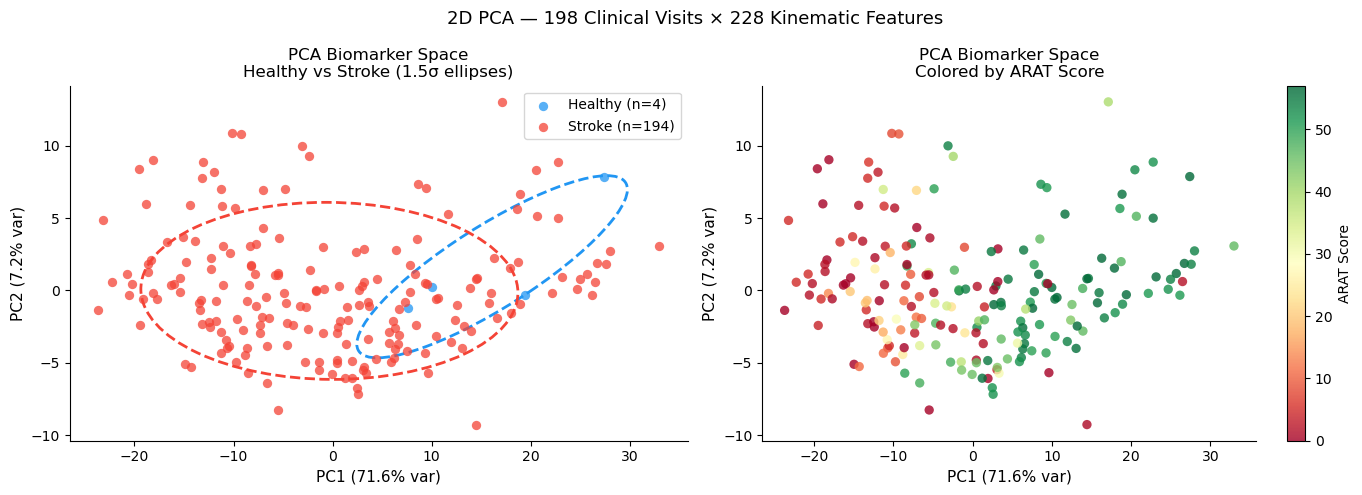

In [16]:
def confidence_ellipse(x, y_vals, ax, n_std=1.5, **kwargs):
    if len(x) < 3:
        return
    cov      = np.cov(x, y_vals)
    pearson  = cov[0,1] / np.sqrt(cov[0,0] * cov[1,1])
    rx, ry   = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ell      = Ellipse((0,0), width=rx*2, height=ry*2, facecolor='none', **kwargs)
    scale_x  = np.sqrt(cov[0,0]) * n_std
    scale_y  = np.sqrt(cov[1,1]) * n_std
    transf   = (transforms.Affine2D()
                .rotate_deg(45)
                .scale(scale_x, scale_y)
                .translate(np.mean(x), np.mean(y_vals)))
    ell.set_transform(transf + ax.transData)
    ax.add_patch(ell)
 
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)
var_exp  = pca.explained_variance_ratio_ * 100
 
print(f'\nPC1: {var_exp[0]:.1f}%  PC2: {var_exp[1]:.1f}%  Combined: {var_exp.sum():.1f}%')
 
group_colors = {0: '#2196F3', 1: '#F44336'}
group_names  = {0: 'Healthy', 1: 'Stroke'}
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
ax = axes[0]
for grp in [0, 1]:
    mask = y == grp
    ax.scatter(X_pca[mask,0], X_pca[mask,1],
               c=group_colors[grp], label=f'{group_names[grp]} (n={mask.sum()})',
               alpha=0.75, s=45, linewidths=0, zorder=3)
    confidence_ellipse(X_pca[mask,0], X_pca[mask,1], ax, n_std=1.5,
                       edgecolor=group_colors[grp], linewidth=2, linestyle='--')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% var)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% var)', fontsize=11)
ax.set_title('PCA Biomarker Space\nHealthy vs Stroke (1.5σ ellipses)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
 
ax = axes[1]
sc = ax.scatter(X_pca[:,0], X_pca[:,1], c=arat, cmap='RdYlGn',
                alpha=0.80, s=45, linewidths=0, vmin=0, vmax=57)
plt.colorbar(sc, ax=ax, label='ARAT Score')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% var)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% var)', fontsize=11)
ax.set_title('PCA Biomarker Space\nColored by ARAT Score', fontsize=12)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
 
plt.suptitle('2D PCA — 198 Clinical Visits × 228 Kinematic Features', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pca_biomarker_space.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7 — Longitudinal Sensitivity

We assess whether stroke survivors' feature representations shift over time — specifically, whether subjects with multiple visits move toward the healthy cluster as recovery progresses. Subjects with ≥ 2 visits are plotted as trajectory lines in PCA space, with arrows indicating the temporal direction of change.

In [17]:
healthy_centroid = X_pca[y == 0].mean(axis=0)   # (2,)
dist_to_healthy  = np.linalg.norm(X_pca - healthy_centroid, axis=1)  # (198,)
 
# Spearman correlation: distance vs weeks (stroke only)
stroke_mask = y == 1
rho_dist_weeks, p_dist_weeks = spearmanr(weeks[stroke_mask], dist_to_healthy[stroke_mask])
print(f'\nDistance-to-healthy-centroid vs clinical week (stroke):')
print(f'  Spearman ρ = {rho_dist_weeks:.3f}  p = {p_dist_weeks:.4f}')
 
# Per-subject linear slope of distance over time
visit_counts = pd.Series(pids[stroke_mask]).value_counts()
multi_pids   = visit_counts[visit_counts >= 3].index.tolist()


Distance-to-healthy-centroid vs clinical week (stroke):
  Spearman ρ = -0.019  p = 0.7932


In [18]:
slopes = []
for pid in multi_pids:
    mask_pid = stroke_mask & (pids == pid)
    w  = weeks[mask_pid].astype(float)
    dt = dist_to_healthy[mask_pid]
    if len(w) < 3:
        continue
    order = np.argsort(w)
    w, dt = w[order], dt[order]
    slope = np.polyfit(w, dt, 1)[0]   # negative slope = moving toward healthy
    slopes.append({'pid': pid, 'n_visits': mask_pid.sum(), 'slope': slope})
 
slopes_df = pd.DataFrame(slopes)
n_improving = (slopes_df['slope'] < 0).sum()
n_total     = len(slopes_df)
print(f'\nSubjects with ≥3 visits: {n_total}')
print(f'Improving (slope < 0, moving toward healthy cluster): {n_improving}/{n_total} '
      f'({100*n_improving/n_total:.0f}%)')
print(f'Mean slope: {slopes_df["slope"].mean():.4f}  '
      f'(negative = moving toward healthy centroid)')
 
# One-sample t-test: are slopes significantly negative?
from scipy.stats import ttest_1samp
t_stat, p_slope = ttest_1samp(slopes_df['slope'], 0)
print(f'One-sample t-test (slopes vs 0): t={t_stat:.3f}, p={p_slope:.4f}')
 
slopes_df.to_csv(os.path.join(METRICS_DIR, 'longitudinal_slopes.csv'), index=False)
 


Subjects with ≥3 visits: 31
Improving (slope < 0, moving toward healthy cluster): 14/31 (45%)
Mean slope: 0.1501  (negative = moving toward healthy centroid)
One-sample t-test (slopes vs 0): t=1.001, p=0.3249


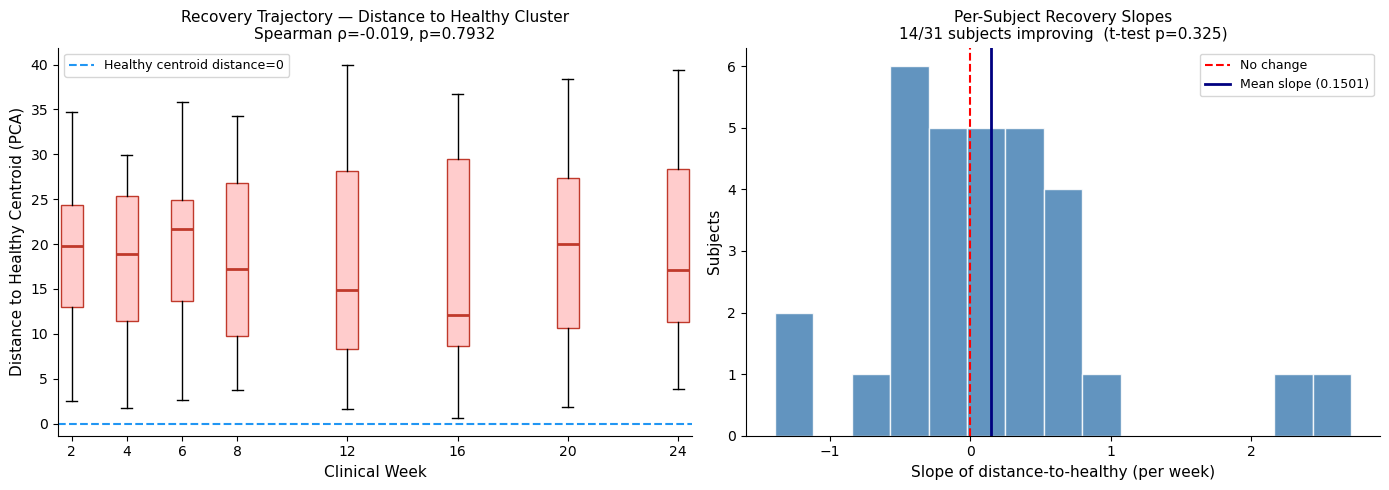

Saved → results/figures/longitudinal_distance.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
ax = axes[0]
# Box plot of distance per week (stroke only, weeks with ≥3 data points)
week_dist = pd.DataFrame({'week': weeks[stroke_mask],
                           'dist': dist_to_healthy[stroke_mask]})
week_groups = {w: g['dist'].values for w, g in week_dist.groupby('week')
               if len(g) >= 3}
sorted_weeks = sorted(week_groups)
ax.boxplot([week_groups[w] for w in sorted_weeks],
           positions=sorted_weeks, widths=0.8,
           patch_artist=True,
           boxprops=dict(facecolor='#ffcccc', color='#c0392b'),
           medianprops=dict(color='#c0392b', lw=2))
ax.axhline(0, color='#2196F3', ls='--', lw=1.5, label='Healthy centroid distance=0')
ax.set_xlabel('Clinical Week', fontsize=11)
ax.set_ylabel('Distance to Healthy Centroid (PCA)', fontsize=11)
ax.set_title(f'Recovery Trajectory — Distance to Healthy Cluster\nSpearman ρ={rho_dist_weeks:.3f}, p={p_dist_weeks:.4f}', fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
 
ax = axes[1]
ax.hist(slopes_df['slope'], bins=15, color='steelblue', alpha=0.85, edgecolor='white')
ax.axvline(0, color='red', lw=1.5, ls='--', label='No change')
ax.axvline(slopes_df['slope'].mean(), color='navy', lw=2,
           label=f'Mean slope ({slopes_df["slope"].mean():.4f})')
ax.set_xlabel('Slope of distance-to-healthy (per week)', fontsize=11)
ax.set_ylabel('Subjects', fontsize=11)
ax.set_title(f'Per-Subject Recovery Slopes\n{n_improving}/{n_total} subjects improving  '
             f'(t-test p={p_slope:.3f})', fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'longitudinal_distance.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/longitudinal_distance.png')

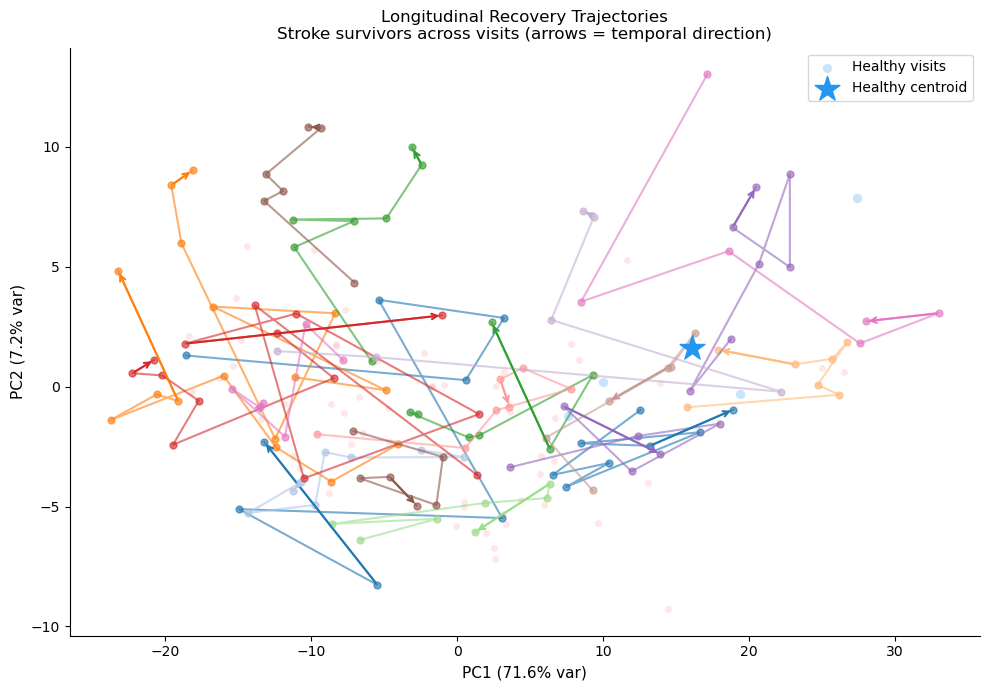

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))
 
ax.scatter(X_pca[y==1, 0], X_pca[y==1, 1], c='#F44336', alpha=0.12, s=25, linewidths=0)
ax.scatter(X_pca[y==0, 0], X_pca[y==0, 1], c='#2196F3', alpha=0.25, s=45,
           linewidths=0, zorder=4, label='Healthy visits')
ax.scatter(*healthy_centroid, marker='*', s=350, c='#2196F3', zorder=6,
           label='Healthy centroid')
 
cmap_traj = plt.cm.get_cmap('tab20', len(multi_pids))
for ci, pid in enumerate(multi_pids[:20]):
    mask = (pids == pid) & (y == 1)
    if mask.sum() < 2:
        continue
    order = np.argsort(weeks[mask])
    xs = X_pca[mask][order, 0]
    ys = X_pca[mask][order, 1]
    color = cmap_traj(ci)
    ax.plot(xs, ys, '-o', color=color, alpha=0.6, markersize=5, lw=1.5)
    if len(xs) >= 2:
        ax.annotate('', xy=(xs[-1], ys[-1]), xytext=(xs[-2], ys[-2]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
 
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% var)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% var)', fontsize=11)
ax.set_title('Longitudinal Recovery Trajectories\n'
             'Stroke survivors across visits (arrows = temporal direction)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'longitudinal_trajectory.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8 - Responsiveness: Standardized Response Mean (SRM)


SRM Responsiveness (36 subject first→last pairs):
  Large |SRM| > 0.80 : 0 features
  Medium |SRM| > 0.50 : 1 features

Top 10 most responsive features (largest |SRM|):
        feature      SRM  abs_SRM
 X_jerk_max_p50 0.509440 0.509440
 X_jerk_std_iqr 0.498967 0.498967
X_jerk_max_mean 0.486707 0.486707
 X_jerk_max_iqr 0.479214 0.479214
 X_jerk_std_p50 0.465997 0.465997
X_jerk_std_mean 0.458801 0.458801
 X_jerk_max_p90 0.423473 0.423473
 Z_jerk_std_p10 0.384271 0.384271
  X_acc_max_p50 0.378591 0.378591
 X_jerk_max_p10 0.377296 0.377296


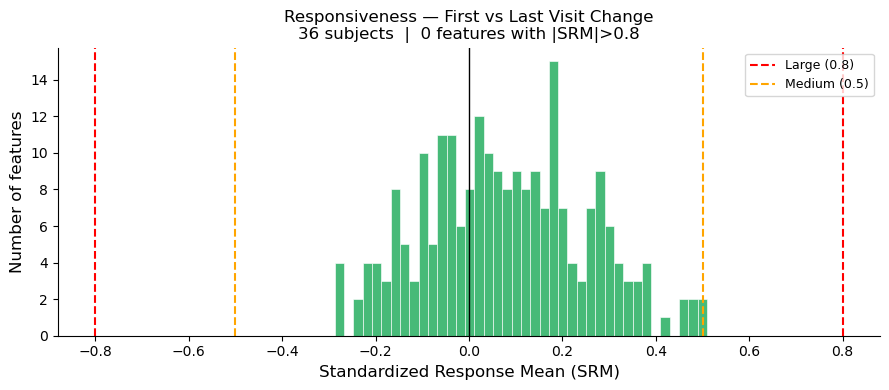

Saved → results/figures/srm_responsiveness.png


In [24]:
srm_pairs = []
for pid in np.unique(pids[stroke_mask]):
    mask_pid  = stroke_mask & (pids == pid)
    w_pid     = weeks[mask_pid]
    if w_pid.nunique() < 2 if hasattr(w_pid, 'nunique') else len(np.unique(w_pid)) < 2:
        continue
    order     = np.argsort(w_pid)
    idx_all   = np.where(mask_pid)[0]
    first_idx = idx_all[order[0]]
    last_idx  = idx_all[order[-1]]
    srm_pairs.append((first_idx, last_idx))
 
if len(srm_pairs) >= 5:
    first_idx_arr = np.array([p[0] for p in srm_pairs])
    last_idx_arr  = np.array([p[1] for p in srm_pairs])
    X_first = X[first_idx_arr]   # (N_pairs, 228)
    X_last  = X[last_idx_arr]
 
    changes = X_last - X_first   # positive = increased from first to last visit
    srm_vals = []
    for i in range(X.shape[1]):
        chg = changes[:, i]
        srm = chg.mean() / (chg.std() + 1e-12)
        srm_vals.append((feature_names[i], float(srm), float(abs(srm))))
 
    srm_df = pd.DataFrame(srm_vals, columns=['feature', 'SRM', 'abs_SRM'])
    srm_df.to_csv(os.path.join(METRICS_DIR, 'srm_responsiveness.csv'), index=False)
 
    n_large = (srm_df['abs_SRM'] > 0.8).sum()
    n_med   = ((srm_df['abs_SRM'] > 0.5) & (srm_df['abs_SRM'] <= 0.8)).sum()
    print(f'\nSRM Responsiveness ({len(srm_pairs)} subject first→last pairs):')
    print(f'  Large |SRM| > 0.80 : {n_large} features')
    print(f'  Medium |SRM| > 0.50 : {n_med} features')
 
    print('\nTop 10 most responsive features (largest |SRM|):')
    print(srm_df.sort_values('abs_SRM', ascending=False).head(10).to_string(index=False))
 
    # ── Figure 5: SRM Distribution ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(srm_df['SRM'], bins=40, color='#27ae60', alpha=0.85, edgecolor='white', lw=0.5)
    ax.axvline(0.8,  color='red',    lw=1.5, ls='--', label='Large (0.8)')
    ax.axvline(-0.8, color='red',    lw=1.5, ls='--')
    ax.axvline(0.5,  color='orange', lw=1.5, ls='--', label='Medium (0.5)')
    ax.axvline(-0.5, color='orange', lw=1.5, ls='--')
    ax.axvline(0,    color='black',  lw=1,   ls='-')
    ax.set_xlabel('Standardized Response Mean (SRM)', fontsize=12)
    ax.set_ylabel('Number of features', fontsize=12)
    ax.set_title(f'Responsiveness — First vs Last Visit Change\n'
                 f'{len(srm_pairs)} subjects  |  {n_large} features with |SRM|>0.8', fontsize=12)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'srm_responsiveness.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIGURES_DIR}/srm_responsiveness.png')
else:
    print(f'Only {len(srm_pairs)} pairs — skipping SRM (need ≥5).')
    srm_df = pd.DataFrame(columns=['feature','SRM','abs_SRM'])
 

## 9 — PCA Interpretability Analysis


Top 15 features on PC1:
  +0.0779  acc_mag_mean_mean
  +0.0778  acc_mag_max_mean
  +0.0772  acc_mag_std_mean
  +0.0769  acc_mag_max_p50
  +0.0766  acc_mag_mean_p50
  +0.0765  acc_mag_std_p50
  +0.0760  acc_mag_mean_p90
  +0.0758  Z_acc_std_mean
  +0.0758  acc_mag_max_p90
  +0.0757  Y_acc_max_mean
  +0.0756  Z_acc_max_mean
  +0.0752  Y_acc_std_mean
  +0.0752  Z_acc_std_p90
  +0.0751  Z_acc_max_p90
  +0.0749  vel_mag_mean_mean

Top 10 features on PC2:
  +0.1825  X_jerk_max_p10
  +0.1793  X_jerk_std_p10
  +0.1453  jerk_mag_mean_p10
  +0.1452  X_vel_max_p10
  +0.1403  X_jerk_std_p50
  +0.1367  X_jerk_std_mean
  +0.1364  X_jerk_max_p50
  +0.1302  jerk_mag_mean_mean
  +0.1268  jerk_mag_mean_p50
  +0.1244  Y_jerk_max_p10


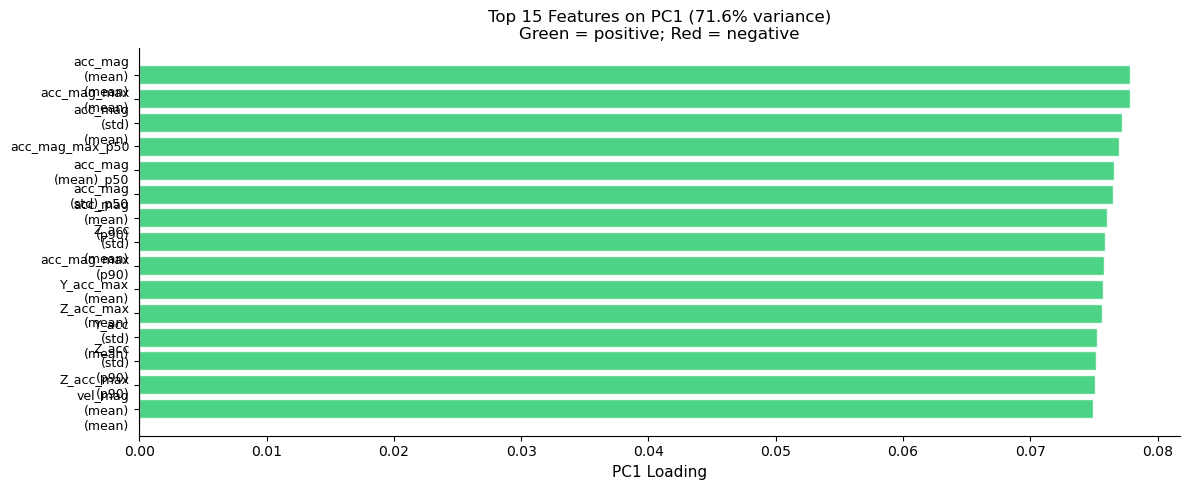

In [25]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1','PC2'], index=feature_names)
top_pc1  = loadings['PC1'].abs().sort_values(ascending=False).head(15)
top_pc2  = loadings['PC2'].abs().sort_values(ascending=False).head(15)
 
print('\nTop 15 features on PC1:')
for fname, val in top_pc1.items():
    sign = '+' if loadings.loc[fname, 'PC1'] > 0 else '–'
    print(f'  {sign}{val:.4f}  {fname}')
 
print('\nTop 10 features on PC2:')
for fname, val in top_pc2.head(10).items():
    sign = '+' if loadings.loc[fname, 'PC2'] > 0 else '–'
    print(f'  {sign}{val:.4f}  {fname}')
 
loadings.to_csv(os.path.join(METRICS_DIR, 'pca_loadings.csv'))
 
# ── Figure 6: PC1 Loadings Bar Chart ─────────────────────────────────────────
top15_names  = top_pc1.index.tolist()
top15_vals   = loadings.loc[top15_names, 'PC1'].values
bar_colors   = ['#2ecc71' if v > 0 else '#e74c3c' for v in top15_vals]
short_labels = [n.replace('_mean','\n(mean)').replace('_std','\n(std)')
                 .replace('_p90','\n(p90)').replace('_p10','\n(p10)')
                 .replace('_iqr','\n(iqr)') for n in top15_names]
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(range(15), top15_vals[::-1], color=bar_colors[::-1], alpha=0.85, edgecolor='white')
ax.set_yticks(range(15))
ax.set_yticklabels(short_labels[::-1], fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('PC1 Loading', fontsize=11)
ax.set_title(f'Top 15 Features on PC1 ({var_exp[0]:.1f}% variance)\n'
             'Green = positive; Red = negative', fontsize=12)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pca_loadings_pc1.png'), dpi=150, bbox_inches='tight')
plt.show()
 

## 10 — Output Summary

In [26]:
n_icc_excellent  = (icc_df['ICC'] > 0.75).sum()
n_icc_good       = ((icc_df['ICC'] > 0.60) & (icc_df['ICC'] <= 0.75)).sum()
n_icc_pearson    = (icc_df['pearson_r'] > 0.90).sum()
n_valid_strong   = (corr_df['rho_ARAT'].abs() > 0.60).sum()
n_valid_moderate = (corr_df['rho_ARAT'].abs() > 0.40).sum()
n_large_d        = (effect_df['abs_d'] > 0.80).sum()
n_medium_d       = (effect_df['abs_d'] > 0.50).sum()
n_large_srm      = (srm_df['abs_SRM'] > 0.80).sum() if len(srm_df) else 'N/A'
 
summary = pd.DataFrame({
    'Criterion': [
        'Reliability: ICC > 0.75 (excellent)',
        'Reliability: ICC > 0.60 (good)',
        'Reliability: Pearson r > 0.90 (even vs odd)',
        'Validity: |ρ_ARAT| > 0.60 (strong)',
        'Validity: |ρ_ARAT| > 0.40 (moderate)',
        'Validity: Bonferroni sig (228 tests)',
        "Effect size: Cohen's d > 0.80 (large)",
        "Effect size: Cohen's d > 0.50 (medium)",
        'Responsiveness: |SRM| > 0.80 (large)',
        'Tier 1 biomarkers (ICC+validity+effect)',
        'Tier 2 biomarkers (validity+effect only)',
    ],
    'N_features': [
        n_icc_excellent, n_icc_good, n_icc_pearson,
        n_valid_strong, n_valid_moderate, corr_df['sig_ARAT'].sum(),
        n_large_d, n_medium_d, n_large_srm,
        len(top_biomarkers), len(tier2)
    ],
    'Pct_of_228': [
        f'{v/228*100:.1f}%' if isinstance(v, (int, np.integer)) else 'N/A'
        for v in [n_icc_excellent, n_icc_good, n_icc_pearson,
                  n_valid_strong, n_valid_moderate, corr_df['sig_ARAT'].sum(),
                  n_large_d, n_medium_d, n_large_srm,
                  len(top_biomarkers), len(tier2)]
    ]
})
 
print('\n=== FULL VALIDATION SUMMARY ===')
print(summary.to_string(index=False))
 
summary.to_csv(os.path.join(METRICS_DIR, 'validation_summary.csv'), index=False)
print(f'\nSaved → {METRICS_DIR}/validation_summary.csv')
 


=== FULL VALIDATION SUMMARY ===
                                  Criterion  N_features Pct_of_228
        Reliability: ICC > 0.75 (excellent)         183      80.3%
             Reliability: ICC > 0.60 (good)          24      10.5%
Reliability: Pearson r > 0.90 (even vs odd)          21       9.2%
         Validity: |ρ_ARAT| > 0.60 (strong)         124      54.4%
       Validity: |ρ_ARAT| > 0.40 (moderate)         204      89.5%
       Validity: Bonferroni sig (228 tests)         208      91.2%
      Effect size: Cohen's d > 0.80 (large)         201      88.2%
     Effect size: Cohen's d > 0.50 (medium)         208      91.2%
       Responsiveness: |SRM| > 0.80 (large)           0       0.0%
    Tier 1 biomarkers (ICC+validity+effect)         180      78.9%
   Tier 2 biomarkers (validity+effect only)         123      53.9%

Saved → results/metrics/validation_summary.csv


In [27]:
expected = [
    (f'{METRICS_DIR}/icc_scores.csv',               'ICC scores per feature'),
    (f'{METRICS_DIR}/clinical_correlation.csv',     'Spearman correlations'),
    (f'{METRICS_DIR}/effect_sizes.csv',             "Cohen's d per feature"),
    (f'{METRICS_DIR}/srm_responsiveness.csv',       'SRM responsiveness'),
    (f'{METRICS_DIR}/longitudinal_slopes.csv',      'Per-subject recovery slopes'),
    (f'{METRICS_DIR}/top_biomarkers.csv',           'Tier 1 biomarkers'),
    (f'{METRICS_DIR}/tier2_biomarkers.csv',         'Tier 2 biomarkers'),
    (f'{METRICS_DIR}/validation_summary.csv',       'Full validation summary'),
    (f'{METRICS_DIR}/pca_loadings.csv',             'PCA loadings'),
    (f'{FIGURES_DIR}/icc_distribution.png',         'ICC + Pearson reliability plot'),
    (f'{FIGURES_DIR}/clinical_correlation_scatter.png', 'Top-4 scatter'),
    (f'{FIGURES_DIR}/validity_by_family.png',       'Validity by feature family'),
    (f'{FIGURES_DIR}/effect_size_distribution.png', "Cohen's d distribution"),
    (f'{FIGURES_DIR}/pca_biomarker_space.png',      'PCA biomarker space'),
    (f'{FIGURES_DIR}/longitudinal_distance.png',    'Distance-to-healthy plot'),
    (f'{FIGURES_DIR}/longitudinal_trajectory.png',  'Trajectory plot'),
    (f'{FIGURES_DIR}/srm_responsiveness.png',       'SRM distribution'),
    (f'{FIGURES_DIR}/pca_loadings_pc1.png',         'PC1 loadings bar chart'),
]
 
all_ok = True
for path, desc in expected:
    ok = os.path.exists(path)
    print(f'  [{"OK" if ok else "MISS"}]  {desc}')
    if not ok:
        all_ok = False
 
print()
print('All outputs ready!' if all_ok else 'Some outputs missing — re-run flagged cells.')
 

  [OK]  ICC scores per feature
  [OK]  Spearman correlations
  [OK]  Cohen's d per feature
  [OK]  SRM responsiveness
  [OK]  Per-subject recovery slopes
  [OK]  Tier 1 biomarkers
  [OK]  Tier 2 biomarkers
  [OK]  Full validation summary
  [OK]  PCA loadings
  [OK]  ICC + Pearson reliability plot
  [OK]  Top-4 scatter
  [OK]  Validity by feature family
  [OK]  Cohen's d distribution
  [OK]  PCA biomarker space
  [OK]  Distance-to-healthy plot
  [OK]  Trajectory plot
  [OK]  SRM distribution
  [OK]  PC1 loadings bar chart

All outputs ready!
